# NASDAQ-100 Microstructure: Feature Engineering

A minute bar of AlgoSeek data carries something a daily bar cannot: the state of the
order book at the close of the bar, and the side of it that the session's trades
crossed. This notebook turns those two into a feature matrix - what liquidity costs,
which way flow is leaning, how far that flow moves the price, and where in the session
the bar sits - states the window and the delay each family carries, and shows that
nothing in it reads a quote dated at or after the decision.

The frame is what makes this case study different from the daily ones. Every window is
bounded by the **symbol-session**, never by the symbol alone, so no statistic spans an
overnight gap; and every cross-sectional statistic is taken over the 114 names quoted in
**that one minute**, which is the cross-section a decision is actually taken over.

## Learning objectives

- Build quote, order-flow, impact and regime families from a raw microstructure schema,
  and say which of them is a signal and which describes the state it is read in
- Bound every trailing window by the session, so a window never reaches across a night
- Measure the session against the exchange's **scheduled** close rather than against the
  bar count the session turned out to have, which is not knowable until it is over
- Lag an input that is published late, rather than assuming a one-minute bar is coarse
  enough to absorb the delay
- Show that withholding later dates leaves every feature value unchanged, which is what
  separates a trailing statistic from one fitted over the whole sample

## Book reference, prerequisites and artifacts

Chapter 8, Sections 8.1-8.6. Reads AlgoSeek NASDAQ-100 minute bars with the full NBBO and
trade-location schema through `load_nasdaq100_bars()`, whose coverage
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the register, every window, the calendar and the
holdout boundary. Writes `features/financial.parquet` with a `.digest.json` sidecar,
read by [`04_model_based_features`](04_model_based_features.ipynb), which adds HAR,
spectral and path-signature features on top of it, and by
[`05_evaluation`](05_evaluation.ipynb), which tests fold by fold whether any of it
predicts. No screen for predictive content runs here: `05_evaluation` owns it and runs it
fold-aware.

In [1]:
"""NASDAQ-100 Microstructure: Feature Engineering."""

import warnings
from datetime import date

import polars as pl
import yaml
from ml4t.diagnostic.splitters.calendar import TradingCalendar
from ml4t.engineer.features.microstructure import amihud_illiquidity

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.feature_engineering import (
    EPS,
    assert_values_agree,
    assign_families,
    families_from_config,
    family_coverage,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    warmup_audit,
)
from data import load_nasdaq100_bars
from utils.paths import display_path, get_case_study_dir

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "nasdaq100_microstructure"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
FEATURES_DIR = CASE_DIR / "features"

All three parameters are read below and all three shorten a run at the cost of a thinner
panel. `MAX_SYMBOLS` keeps a seed-deterministic subset of the universe; the two dates trim
the history. Every cross-sectional statistic in Section C ranks within one minute across
the whole universe, so a capped run computes a different quantity rather than a smaller
one - which is why CI reads the matrix for shape and never for a value.

In [2]:
MAX_SYMBOLS = 0
START_DATE = "2020-01-01"
END_DATE = "2021-12-31"

## Configuration

The register, every window, the calendar and the holdout boundary are declared in
`config/setup.yaml` and bound here. A window retyped into a cell is a second source of
truth for a decision that the register, the warmup assertion and the timing figure all
have to agree on, and the two copies drift apart the first time either is edited.

The decision cadence is what the persistence figure is measured against: a feature has to
hold its ordering for at least one rebalance to be tradable at that cadence, and this
strategy rebalances on the 15-minute grid the configuration declares.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
FEATURES = setup["features"]
FAMILIES = families_from_config(setup)
W = FEATURES["windows"]
CARRIER = FEATURES["carrier"]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
DECISION_MINUTES = int(setup["decision"]["bar_frequency"].removesuffix("_minute"))
CALENDAR = setup["evaluation"]["calendar"]

# The panel key, the entity every trailing window is bounded by, and the partition every
# cross-sectional statistic is taken over.
PANEL_KEY = ["symbol", "timestamp"]
ENTITY = ["symbol", "session_date"]
WITHIN_MINUTE = "timestamp"

print(f"{len(FAMILIES)} declared families, carrier {CARRIER}, decision grid {DECISION_MINUTES}min")
print(f"Holdout starts {HOLDOUT_START}; Section D rebuilds the matrix without it")

7 declared families, carrier signed_vol_share_15m, decision grid 15min
Holdout starts 2021-07-01; Section D rebuilds the matrix without it


## A. What the thesis says should carry information

The hypothesis is short-horizon and it is about pressure rather than value: over the next
fifteen minutes a NASDAQ-100 name drifts in the direction the last few minutes of
aggressive volume have been pushing it, and the drift is small enough that what it costs
to act on it decides whether anything is left. Three things follow.

The **carrier** is order-flow imbalance measured over one decision bar. It is signed
volume as a share of volume, so it is scale-free and a mega-cap and a mid-cap can sit in
one ordering; it is also this case study's causal treatment, which is why the same
quantity is carried at four resolutions rather than one.

The **conditioning** is everything about the environment the carrier is read in: what the
round trip costs, how deep the book is, how far a given quantity of flow moves the price,
how much of the session is printing away from the exchanges, and where in the session the
bar sits. None of these is expected to rank names on its own, which is what the register's
`role` column records and what no assertion can recover from the values.

The **frame** is the symbol-session for every trailing window and the single minute for
every cross-sectional one. A spread is not comparable between AAPL and ALGN, so each level
is carried beside its z-score within the minute, and the register claims both under one
family because they are one hypothesis on two scales.

The register is declared in `config/setup.yaml`, one row per family, and it is split by
**observability** rather than by economics: the three families read off the NBBO carry no
lag, and the three built from the trade tape carry one bar, for the reason Section B gives.
That is why volatility and price impact are separate rows although they describe the same
thing - a quote-based variance is knowable at the bar it is stamped with and a traded-dollar
statistic is not, and a register row cannot carry two lags.

In [4]:
register_frame(FAMILIES).select(
    ["family", "role", "inputs", "lookback (bars)", "lag (bars)", "frame"]
)

family,role,inputs,lookback (bars),lag (bars),frame
str,str,str,i64,i64,str
"""quote_liquidity""","""state""","""NBBO close quotes, quote updat…",60,0,"""per symbol-session, trailing"""
"""microprice""","""signal""","""NBBO close prices and sizes""",15,0,"""per symbol-session, trailing"""
"""volatility""","""state""","""NBBO quote midpoint and quote …",60,0,"""per symbol-session, trailing"""
"""order_flow""","""signal""","""AlgoSeek trade-location and ti…",60,1,"""per symbol-session, trailing"""
"""price_impact""","""state""","""consolidated trade prices, tra…",60,1,"""per symbol-session, trailing"""
"""hidden_liquidity""","""state""","""FINRA/TRF reported volume, tot…",60,1,"""per symbol-session, trailing"""
"""session_clock""","""state""","""exchange calendar""",0,0,"""per session, from the schedule…"


## B. Inputs and their observability

Each row is one symbol and one minute of one session. Of the sixty columns the raw
AlgoSeek schema carries, sixteen are read; projecting at the scan is what keeps a
full-universe run inside a few gigabytes rather than the twenty-eight the whole schema
costs. Regular hours only - the pre-market and after-hours books are thin enough that
their quotes describe a different market.

**Two inputs are not knowable at the bar they are stamped with, and each is handled here
rather than downstream.**

A quote with `nbbo_quote_count == 0` is a bar in which the NBBO never updated, so the
prices on it are carried forward from whenever it last did. One such bar is harmless; a
run of them turns a stale spread into a live-looking one and reports a calm book exactly
where the book has stopped. Quote-derived columns are nulled beyond the configured run of
consecutive stale bars, which is the single data policy the rest of the notebook inherits.

FINRA/TRF prints are reported with a delay of up to ten seconds. A print executed in the
last seconds of a bar can therefore be attributed to that bar while still being unpublished
at its close.

That delay is not confined to the off-exchange share, and this is the part worth being
careful about. The trade-location and tick buckets are TRF-inclusive, so **every** feature
built from the trade tape - the order-flow shares, the traded dollars, Amihud, the trade
range - carries the same unpublished prints. Whether the vendor stamps a TRF print by
execution time or by the time it reached the tape is not documented in the data contract,
so the conservative reading is the one taken here.

Each of those features is still **computed** on the bar it describes, and only then shifted
by the lag its register row declares. The order matters: Amihud and Kyle's lambda relate a
return to the flow that moved it, so building them from a lagged tape against an unlagged
quote return would pair this bar's move with last bar's flow and measure nothing. Compute
the same-bar quantity, then publish it late.

In [5]:
OPEN_HOUR, OPEN_MINUTE, CLOSE_HOUR = 9, 30, 16
_hour, _minute = pl.col("timestamp").dt.hour(), pl.col("timestamp").dt.minute()
REGULAR_HOURS = ((_hour > OPEN_HOUR) | ((_hour == OPEN_HOUR) & (_minute >= OPEN_MINUTE))) & (
    _hour < CLOSE_HOUR
)
READ = [
    "timestamp",
    "symbol",
    "close_bid_price",
    "close_ask_price",
    "close_bid_size",
    "close_ask_size",
    "nbbo_quote_count",
    "high_trade_price",
    "low_trade_price",
    "high_ask_price",
    "low_bid_price",
    "vwap",
    "volume",
    "total_trades",
    "finra_volume",
    "finra_vwap",
    "trade_at_bid",
    "trade_at_bid_mid",
    "trade_at_mid_ask",
    "trade_at_ask",
    "trade_at_cross",
    "uptick_volume",
    "downtick_volume",
    "repeat_uptick_volume",
    "repeat_downtick_volume",
    "trade_to_mid_vol_weight_rel",
]

bars = (
    load_nasdaq100_bars(
        start_date=START_DATE,
        end_date=END_DATE,
        include_microstructure=True,
        max_symbols=MAX_SYMBOLS,
        lazy=True,
    )
    .select(READ)
    .filter(REGULAR_HOURS)
    .with_columns(pl.col("timestamp").dt.date().alias("session_date"))
    .collect()
    .sort([*ENTITY, "timestamp"])
)

LOADER_COLS = {*READ, "session_date"}
print(f"{bars.height:,} regular-hours bars, {bars['symbol'].n_unique()} symbols")
print(
    f"{bars['session_date'].n_unique():,} sessions, {bars['timestamp'].min()} to {bars['timestamp'].max()}"
)

19,908,044 regular-hours bars, 114 symbols
505 sessions, 2020-01-02 09:30:00 to 2021-12-31 15:59:00


In [6]:
QUOTE_COLS = ["close_bid_price", "close_ask_price", "close_bid_size", "close_ask_size"]


def cap_stale_quotes(df: pl.DataFrame) -> pl.DataFrame:
    """Null the quote sides once the NBBO has failed to update for too many bars.

    The run length is a trailing count within the symbol-session, so a bar is judged on
    the bars before it and never on the bars after it.
    """
    cap = W["stale_cap"]
    run = (pl.col("nbbo_quote_count") == 0).cast(pl.Int32).rolling_sum(cap + 1).over(ENTITY)
    return df.with_columns(run.alias("_stale_run")).with_columns(
        pl.when(pl.col("_stale_run") > cap).then(None).otherwise(pl.col(c)).alias(c)
        for c in QUOTE_COLS
    )

In [7]:
_capped = cap_stale_quotes(bars)["_stale_run"]
print(
    f"Staleness cap: {(_capped > W['stale_cap']).sum():,} bars "
    f"({(_capped > W['stale_cap']).mean():.3%}) ran more than {W['stale_cap']} stale quotes"
)

Staleness cap: 27,857 bars (0.142%) ran more than 5 stale quotes


The session's length is taken from the exchange calendar rather than from the bars. Both
answers agree on a full session and they do not agree on an early close: the vendor emits
a padded 390-bar grid on every date, so a half-session's realized bar count says 390 where
the exchange closed after 210. Counting from the schedule is also the only form of the
quantity a trader had at the open, which is the property Section D.1 turns on.

In [8]:
_schedule = TradingCalendar(CALENDAR).calendar.schedule(start_date=START_DATE, end_date=END_DATE)
sessions = pl.DataFrame(
    {
        "session_date": [d.date() for d in _schedule.index],
        "session_bars": (
            (_schedule["market_close"] - _schedule["market_open"]).dt.total_seconds() // 60
        ).astype("int32"),
    }
)
SHORT = sessions.filter(pl.col("session_bars") < sessions["session_bars"].max())
print(f"{sessions.height} scheduled sessions, {SHORT.height} of them early closes")
print(f"scheduled lengths in bars: {sorted(sessions['session_bars'].unique().to_list())}")

505 scheduled sessions, 3 of them early closes
scheduled lengths in bars: [210, 390]


## C. Feature construction

### C.1 Quote liquidity and the microprice

The midpoint of the closing NBBO is the fair value a return is taken between, the spread
relative to it is the round trip a signal has to clear, and the depth-weighted price -
the microprice - leans toward the thin side of the book. Its **deviation** from the
midpoint is the informative quantity rather than its level (Stoikov, 2018): the level is
a price and moves with the stock, the deviation is a pressure and does not.

Every ratio takes the shared denominator guard rather than a locally invented one. Five
different guards shipped across the nine case studies, which made otherwise identical
features incomparable.

In [9]:
def quote_features(df: pl.DataFrame) -> pl.DataFrame:
    """Cost, depth and pressure, read off the closing NBBO of each bar."""
    bid, ask = pl.col("close_bid_price"), pl.col("close_ask_price")
    bid_size, ask_size = pl.col("close_bid_size"), pl.col("close_ask_size")
    mid = (bid + ask) / 2
    depth = (bid_size + ask_size).clip(lower_bound=EPS)
    micro = (ask * bid_size + bid * ask_size) / depth
    return df.with_columns(
        mid.alias("mid_close"),
        ((ask - bid) / mid.clip(lower_bound=EPS)).alias("rel_spread_close"),
        (micro - mid).alias("microprice_dev"),
        ((bid_size - ask_size) / depth).alias("depth_imb"),
        pl.col("nbbo_quote_count").cast(pl.Float64).alias("quote_rate"),
    )

### C.2 Order flow

AlgoSeek reports each bar's volume split by where the trade printed against the prevailing
quote, which is what makes a signed volume possible without a tick rule. Volume that
crossed at or above the midpoint was buyer-initiated and volume at or below it was
seller-initiated; the difference is aggressive net demand, and dividing it by the volume
it was measured over makes a share that ranks across the universe. The tick imbalance asks
the same question of the direction of successive prints rather than of their location.

**Which volume it is divided by is the whole of whether the result is a share.** The
location and tick buckets cover every trade in the bar, including the ones reported to the
FINRA/TRF rather than to an exchange, while `volume` counts the exchange prints alone: the
six location buckets sum to `volume + finra_volume` on every bar of this panel, and to
`volume` only on the small minority of bars where nothing printed away from the exchanges.
`total_trades` counts on the same basis - a bar with no exchange volume and a TRF print
still reports trades. Dividing by `volume` therefore divides a total by a part, which is
what the version this notebook shipped did: its shares ran far outside $[-1, 1]$, which is
not a scale but a contradiction in terms. The assertion below is what turns that into a
failure instead of a number nobody looks at.

The volume every share in this family is a share *of*: the exchange prints plus the ones
reported away from the exchanges, which is what the buckets themselves are counted over.

`DOLLAR_VOLUME` is the dollars behind that volume, from both venues. Each side's VWAP is
null exactly where that side traded nothing, so each product is taken as zero there and the
bar is null only when neither venue printed - the one case in which "dollars traded" has no
value rather than a small one.

In [10]:
TRADED_VOLUME = (pl.col("volume") + pl.col("finra_volume")).clip(lower_bound=1)
DOLLAR_VOLUME = (
    pl.when((pl.col("volume") + pl.col("finra_volume")) > 0)
    .then(
        pl.col("vwap").fill_null(0.0) * pl.col("volume")
        + pl.col("finra_vwap").fill_null(0.0) * pl.col("finra_volume")
    )
    .otherwise(None)
)


def order_flow_features(df: pl.DataFrame) -> pl.DataFrame:
    """Which side paid the spread, as a share of everything the bar traded."""
    signed = (pl.col("trade_at_ask") + pl.col("trade_at_mid_ask")) - (
        pl.col("trade_at_bid") + pl.col("trade_at_bid_mid")
    )
    ticked = (pl.col("uptick_volume") + pl.col("repeat_uptick_volume")) - (
        pl.col("downtick_volume") + pl.col("repeat_downtick_volume")
    )
    return df.with_columns(
        signed.alias("signed_vol"),
        ticked.alias("tick_imb_vol"),
        (signed / TRADED_VOLUME).alias("signed_vol_share"),
        (ticked / TRADED_VOLUME).alias("tick_imb_share"),
        pl.col("trade_to_mid_vol_weight_rel").alias("trade_to_mid_rel"),
        (pl.col("total_trades") / TRADED_VOLUME * 1000).alias("trades_per_1k_shares"),
        (pl.col("trade_at_cross") / TRADED_VOLUME).alias("cross_locked_share"),
    )

### C.3 Volatility, range and price impact

Returns are taken between quote midpoints rather than between trade prices, because a
trade series alternates between the bid and the ask as buyers and sellers arrive and a
return taken across that alternation carries a bounce with no information in it
(Hasbrouck, 2007). Realized volatility at three horizons and an EWMA of the same series
describe how much uncertainty a signal is being read against.

Two impact measures answer the same question on different data. **Amihud illiquidity** is
the library's estimator, and it is an *average* of the absolute return per dollar traded
over a window - not the single-bar ratio that this notebook previously shipped under the
name, which is a much noisier quantity with a different scale. It is null on a bar that
printed no trades at all, because price impact per dollar traded is undefined when nothing
traded. **Kyle's lambda** regresses the return on the signed share over a rolling hour
and is kept local: the identity form below has a warmup of exactly its window where a
two-pass covariance would need twice that.

**Dollar volume counts both venues, for the same reason the order-flow denominator does.**
`vwap` and `volume` describe the exchange prints alone, and a bar whose trades all printed
to the TRF would otherwise report no dollars traded and no price impact - which is not that
the bar was quiet but that this notebook was looking at one venue. The two venues' dollars
are added, and the price Amihud is given is the volume-weighted average across both, so
each venue's shares are priced at the average they actually traded at.

In [11]:
def volatility_features(df: pl.DataFrame) -> pl.DataFrame:
    """Uncertainty and price impact, over windows bounded by the session."""
    ret = pl.col("mid_close").log().diff().over(ENTITY)
    df = df.with_columns(ret.alias("r1m"))
    return df.with_columns(
        *[
            pl.col("r1m").rolling_std(w).over(ENTITY).alias(f"rv_{w}m")
            for w in (W["fast"], W["decision"], W["slow"])
        ],
        pl.col("r1m")
        .pow(2)
        .ewm_mean(half_life=W["ewma_half_life"])
        .over(ENTITY)
        .sqrt()
        .alias(f"rv_ewma_{W['ewma_half_life']}m"),
        (pl.col("high_trade_price").log() - pl.col("low_trade_price").log()).alias("trade_range"),
        (pl.col("high_ask_price").log() - pl.col("low_bid_price").log()).alias("quote_range"),
        DOLLAR_VOLUME.alias("dollar_vol"),
        amihud_illiquidity(
            returns=pl.col("r1m"),
            volume=TRADED_VOLUME,
            price=DOLLAR_VOLUME / TRADED_VOLUME,
            period=W["slow"],
        )
        .over(ENTITY)
        .alias("illiq"),
    )

In [12]:
def kyle_lambda(df: pl.DataFrame) -> pl.DataFrame:
    """Price impact per unit of signed order flow, over a rolling hour (Kyle, 1985).

    Built from the single-pass identities cov(r, s) = E[rs] - E[r]E[s] and
    var(s) = E[s^2] - E[s]^2, so the warmup is exactly the window rather than twice it.
    """
    window = W["hour"]
    r, s = pl.col("r1m"), pl.col("signed_vol_share")
    return (
        df.with_columns(
            r.rolling_mean(window).over(ENTITY).alias("_r"),
            s.rolling_mean(window).over(ENTITY).alias("_s"),
            (r * s).rolling_mean(window).over(ENTITY).alias("_rs"),
            s.pow(2).rolling_mean(window).over(ENTITY).alias("_ss"),
        )
        .with_columns(
            (
                (pl.col("_rs") - pl.col("_r") * pl.col("_s"))
                / (pl.col("_ss") - pl.col("_s").pow(2)).clip(lower_bound=EPS)
            ).alias("kyle_lambda")
        )
        .drop("_r", "_s", "_rs", "_ss")
    )

### C.4 Hidden liquidity and the session clock

The FINRA share is the fraction of a bar's volume that printed away from the exchanges. It
is computed on its own bar like everything else and shifted afterwards, along with the two
other trade-derived families, by `publish_with_lag`.

The session clock is where the previous version of this notebook was wrong, and the error
is worth naming because it is invisible in the values. It divided the bar's position by
the session's **realized** bar count, taken as a maximum over the whole symbol-session -
a quantity that does not exist until the session is over. Here the position is counted
from the clock, against the length the exchange **scheduled**, and both are knowable at
the open. The block flags mark the configured window at each end of the scheduled session,
so a bar the vendor emits after an early close falls in neither.

In [13]:
def regime_and_clock_features(df: pl.DataFrame) -> pl.DataFrame:
    """The slow off-exchange regime, and where in the scheduled session a bar sits."""
    finra = pl.col("finra_volume") / TRADED_VOLUME
    # `dt.hour()` and `dt.minute()` are Int8, and Int8 arithmetic wraps rather than raising:
    # 9 * 60 is 28, not 540. Both are widened before the multiplication.
    hour = pl.col("timestamp").dt.hour().cast(pl.Int32)
    minute = pl.col("timestamp").dt.minute().cast(pl.Int32)
    bar = hour * 60 + minute - (OPEN_HOUR * 60 + OPEN_MINUTE)
    length = pl.col("session_bars")
    edge = W["edge_block"]
    return df.with_columns(
        finra.rolling_mean(W["hour"]).over(ENTITY).alias("finra_share_60m"),
        bar.alias("bar_of_day"),
        (bar / length).clip(0.0, 1.0).alias("time_since_open"),
        (1.0 - bar / length).clip(0.0, 1.0).alias("time_to_close"),
        (bar < edge).cast(pl.Float64).alias("is_first_30m"),
        ((bar >= length - edge) & (bar < length)).cast(pl.Float64).alias("is_last_30m"),
    )

### C.5 Multi-resolution aggregates and the cross-section

Microstructure signals decay at different rates - an order-flow imbalance reverts within
minutes while a spread dislocation persists - so the fast families are carried at the
fast, decision and hourly windows and the model is left to learn which horizon holds the
content. The aggregates are ratios of sums rather than means of ratios: over five bars the
question is what share of the *volume traded in those five minutes* was aggressive, which a
mean of five per-bar shares answers only when the five bars carried equal volume.

The cross-sectional z-score is taken **within the minute**, over the names quoted in it,
which is the cross-section a decision is taken over and the only partition that removes a
market-wide move without reaching across time. It is a representation of the same
hypothesis rather than a new one, which is why the register claims a level and its z-score
under one family.

Each entry below is one source column, the stem its aggregates are named on, and the
windows. `SHARES` divides a sum by the volume traded over the same window; `MEANS` averages
a quantity that is already a ratio.

In [14]:
SHARES = {
    "signed_vol": ("signed_vol_share", (W["fast"], W["decision"], W["hour"])),
    "tick_imb_vol": ("tick_imb_share", (W["fast"], W["decision"])),
}
MEANS = {
    "rel_spread_close": ("rel_spread", (W["fast"], W["decision"], W["hour"])),
    "trade_to_mid_rel": ("trade_to_mid", (W["fast"],)),
    "microprice_dev": ("microprice_dev", (W["fast"], W["decision"])),
}


def multi_resolution(df: pl.DataFrame) -> pl.DataFrame:
    """The fast families again, over the fast, decision and hourly windows."""
    return df.with_columns(
        [
            (
                pl.col(source).rolling_sum(w).over(ENTITY)
                / TRADED_VOLUME.rolling_sum(w).over(ENTITY)
            ).alias(f"{stem}_{w}m")
            for source, (stem, windows) in SHARES.items()
            for w in windows
        ]
        + [
            pl.col(source).rolling_mean(w).over(ENTITY).alias(f"{stem}_{w}m")
            for source, (stem, windows) in MEANS.items()
            for w in windows
        ]
    )

The z-score partition is the minute alone. Which columns get one is derived from the
register rather than listed again here: every level a family claims is ranked, except the
session clock, whose values are identical across the cross-section by construction and
whose z-score would therefore be a column of zeros divided by nothing.

The intermediates below are what the families are assembled from, and no model may read
them: a contemporaneous price or an unnormalized volume beside a label derived from the
same midpoint series is a model reading its own answer.

In [15]:
INTERMEDIATE = {
    "mid_close",
    "signed_vol",
    "tick_imb_vol",
    "bar_of_day",
    "session_bars",
    "_stale_run",
}
RANKED_FAMILIES = [f.name for f in FAMILIES if f.name != "session_clock"]
LAGGED_FAMILIES = {f.name for f in FAMILIES if f.lag > 0}


def publish_with_lag(df: pl.DataFrame) -> pl.DataFrame:
    """Shift each family's levels by the lag its register row declares.

    Every feature is computed on the bar it describes, so a price-impact estimator
    relates a return to the flow that moved it rather than to the previous bar's flow.
    The shift is applied afterwards, to the finished quantity, which is what "published
    late" means: the value is about bar t and it is not readable until t + lag.

    Shifting the finished feature and shifting its inputs are the same thing for a
    trailing window over one entity, and they are not the same thing for anything that
    reads two sources. That is the whole of this function's reason to exist.
    """
    levels = [c for c in df.columns if c not in LOADER_COLS and c not in INTERMEDIATE]
    claimed = assign_families(levels, FAMILIES)
    lag = {f.name: f.lag for f in FAMILIES}
    return df.with_columns(
        pl.col(c).shift(lag[family]).over(ENTITY)
        for c, family in claimed.items()
        if family in LAGGED_FAMILIES
    )


def cross_sectional(df: pl.DataFrame) -> pl.DataFrame:
    """The z-score of each level within its own minute, across the quoted universe."""
    levels = [c for c in df.columns if c not in LOADER_COLS and c not in INTERMEDIATE]
    claimed = assign_families(levels, FAMILIES)
    columns = sorted(c for c, family in claimed.items() if family in RANKED_FAMILIES)
    return df.with_columns(
        (
            (pl.col(c) - pl.col(c).mean().over(WITHIN_MINUTE))
            / pl.col(c).std().over(WITHIN_MINUTE).clip(lower_bound=EPS)
        ).alias(f"{c}_xs")
        for c in columns
    )

The six subsections compose into one function, which is what lets D.3 re-run the whole
construction on a shorter panel and compare. The scheduled session length is joined before
the clock family is built, because that family is a statement about the exchange's day
rather than about the panel's rows.

In [16]:
def build_features(bars: pl.DataFrame) -> pl.DataFrame:
    """Every family, in dependency order, on a panel sorted by symbol-session and time."""
    return (
        bars.join(sessions, on="session_date", how="left")
        .pipe(cap_stale_quotes)
        .pipe(quote_features)
        .pipe(order_flow_features)
        .pipe(volatility_features)
        .pipe(kyle_lambda)
        .pipe(regime_and_clock_features)
        .pipe(multi_resolution)
        .pipe(publish_with_lag)
        .pipe(cross_sectional)
        .drop("_stale_run")
    )

In [17]:
built = build_features(bars)
feature_cols = sorted(c for c in built.columns if c not in LOADER_COLS and c not in INTERMEDIATE)
assignment = assign_families(feature_cols, FAMILIES)
print(f"{built.height:,} rows carrying {len(feature_cols)} features in {len(FAMILIES)} families")

19,908,044 rows carrying 66 features in 7 families


A share of a volume cannot exceed that volume, at any of the four windows. This is the
assertion the previous denominator failed, and it is cheaper than the figure that
eventually showed it.

In [18]:
SHARE_COLUMNS = [
    c
    for c in feature_cols
    if c.startswith(("signed_vol_share", "tick_imb_share")) and not c.endswith("_xs")
]
_worst = built.select(pl.max_horizontal([pl.col(c).abs().max() for c in SHARE_COLUMNS])).item()
assert _worst <= 1.0, f"an order-flow share reached {_worst:.1f}, so its denominator is a part"
print(f"{len(SHARE_COLUMNS)} order-flow shares, largest magnitude {_worst:.4f}")

7 order-flow shares, largest magnitude 1.0000


## D. The timing contract

### D.1 What each construction reads

Four kinds of operation appear above. A **rolling** window - every realized volatility, every
multi-resolution aggregate, the Amihud average and the four moments Kyle's lambda is built
from - ends at its own bar and reads a fixed number of earlier bars **within one
symbol-session**, so none of them spans a night. A **shift** appears twice and means two
different things: inside a construction it differences a series, and in `publish_with_lag`
it defers a finished value to the bar at which it could be read. A **contemporaneous**
relation - the spread, the depth imbalance, the microprice deviation, the quote range -
reads one bar's own quote and no other bar at all. A **cross-sectional** statistic - the
z-scores - is taken with `.over("timestamp")`, so it reads every symbol quoted in that
minute and nothing dated before or after it, and it runs after the publication shift so a
minute's cross-section is ranked on what was readable in it.

**Three families are deferred and three are not, and the split is the register's.** Quote
liquidity, the microprice and volatility read the NBBO, which is on the wire when it moves.
Order flow, price impact and hidden liquidity read the trade tape, which carries TRF prints
that may not be published yet - so the trade range is deferred with them, and it is the one
of the two ranges that is not contemporaneous.

The session clock is the fifth thing, and it is the one that was wrong: it reads the
exchange's published schedule, which is knowable before the session opens, rather than the
session's realized bar count, which is not. None of the five is fitted - no bound, scaler or
encoder here has a parameter estimated once and applied to every row. D.2 checks the
windows; D.3 checks all five at once.

### D.2 Warmup

A trailing window cannot produce a value until it has enough bars to fill, and because the
entity is the symbol-session every window warms up again each morning. The audit checks
that length rather than describing it: a column carrying a value before its window could
have filled is reading bars that do not exist, and that is what it raises on. The counts
below are one greater than each window wherever the input is itself a difference, because
a session's first bar has no previous bar to difference against.

In [19]:
warmup_audit(
    built,
    {
        "kyle_lambda": W["hour"] + 1,
        "finra_share_60m": W["hour"] + 1,
        "signed_vol_share_60m": W["hour"],
        "rel_spread_60m": W["hour"],
        "illiq": W["slow"] + 1,
        f"rv_{W['slow']}m": W["slow"] + 1,
        f"rv_{W['decision']}m": W["decision"] + 1,
        "microprice_dev_15m": W["decision"],
        f"rv_{W['fast']}m": W["fast"] + 1,
        "r1m": 2,
    },
    entity=ENTITY,
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""kyle_lambda""",61,62,true
"""finra_share_60m""",61,61,true
"""signed_vol_share_60m""",60,61,true
"""rel_spread_60m""",60,60,true
"""illiq""",31,32,true
"""rv_30m""",31,31,true
"""rv_15m""",16,16,true
"""microprice_dev_15m""",15,15,true
"""rv_5m""",6,6,true


### D.3 Withholding the holdout changes nothing

Trailing, contemporaneous and within-minute statistics share a property worth checking
directly: recomputed on a panel that stops before the holdout, they reproduce the same
values on the rows the two panels share. A parameter fitted over a whole column does not,
because truncating the column moves the parameter and with it every row it was applied to.
Comparing two builds tests every emitted column at once and does not depend on anyone
having flagged the transform that fits. A value on one side against a null on the other
counts as a difference.

The cross-sectional z-score is the column this check exists for. It is taken within a
minute, so truncating the panel at a date removes whole minutes and leaves the surviving
ones with the same membership. A z-score taken over the whole sample is the transform this
check is built to catch: truncating the panel moves its mean and standard deviation, and
with them every row.

In [20]:
_before = pl.col("timestamp").dt.date() < HOLDOUT_START
seal = assert_values_agree(
    built.filter(_before),
    build_features(bars.filter(_before)),
    columns=feature_cols,
    keys=PANEL_KEY,
)
seal.filter(pl.col("column").is_in(["kyle_lambda", f"{CARRIER}_xs", "finra_share_60m"]))

column,rows compared,null only on one side,max abs difference
str,i64,i64,f64
"""finra_share_60m""",14945190,0,0.0
"""kyle_lambda""",14945190,0,0.0
"""signed_vol_share_15m_xs""",14945190,0,0.0


## E. Matrix assembly and coverage

The panel key is `symbol` + `timestamp`. Everything the loader supplied is excluded - the
quote sides and sizes, the trade-location buckets, volume, the VWAP and the quote count -
because a model handed a contemporaneous price beside a label derived from the same
midpoint series would be reading its own answer. The five intermediates the families are
assembled from go with them.

One null policy is applied once: a row is kept when the three carriers of the volatility
and impact family have warmed up, of which Kyle's lambda at an hour is the binding one.
Requiring it subsumes every shorter window in that family, and the longer families of
Section C.5 fill in at the same bar, which is what F1 shows.

What the policy keeps is not everywhere dense, and the gaps are all of one kind. A bar on
which neither venue printed has no dollar volume, no Amihud value and no volume-weighted
trade-to-mid distance; and because the Amihud average nulls a whole window for one missing
bar, a small share of such bars costs far more rows than it occupies. The results cell
below reports both. Those rows keep a null rather than a fabricated number, which is what
F1 shows as the shortfall in the two trade-derived families.

The policy also costs one feature outright, and the arithmetic below states it rather than
leaving it to be discovered. Kyle's lambda needs an hour, so the matrix begins 60 bars into
every session, while `is_first_30m` marks the first 30 - so every bar the flag could be
true of has already been dropped, and the column ships identically zero. The column is kept
because the feature count is what Chapter 8 reports, and the assertion is what stops it
being mistaken for a live signal.

In [21]:
CARRIERS = ["r1m", f"rv_{W['slow']}m", "kyle_lambda"]
features = built.select([*PANEL_KEY, *feature_cols]).drop_nulls(subset=CARRIERS).sort(PANEL_KEY)
assert features.select(PANEL_KEY).is_duplicated().sum() == 0, "duplicate panel key"

No emitted feature may be constant without the notebook saying why. A column with one value
ranks nothing and cannot condition anything, and it is the failure a clipped expression
hides best: the session clock shipped as `time_since_open = 0` on every row of this panel,
because `dt.hour()` is Int8 and `hour * 60` wrapped to 28, after which `.clip(0, 1)` turned
the negative result into a plausible constant. It passed the warmup audit, the holdout seal
and the conformance checker; only the redundancy dendrogram showed it.

In [22]:
DEAD_BY_WARMUP = ["is_first_30m"]
assert W["hour"] >= W["edge_block"], "the open block is inside the warmup only if it is shorter"
assert features["is_first_30m"].max() == 0, "the open block survived a 60-bar warmup"
_variety = features.select(pl.col(c).n_unique().alias(c) for c in feature_cols)
_flat = [c for c in feature_cols if _variety[c][0] <= 1 and c not in DEAD_BY_WARMUP]
assert not _flat, f"features that take a single value across the emitted matrix: {_flat}"
print(f"{len(feature_cols) - len(DEAD_BY_WARMUP)} features vary; {DEAD_BY_WARMUP} dead by warmup")
# The decision grid the strategy rebalances on, which F3, F6 and F7 read. A figure drawn on
# every minute would describe a cadence no decision is taken at.
DECISION_TIMES = (
    features.filter(pl.col("timestamp").dt.minute() % DECISION_MINUTES == 0)["timestamp"]
    .unique()
    .sort()
)
decisions = features.filter(pl.col("timestamp").is_in(DECISION_TIMES))
register_frame(FAMILIES, feature_cols).select(["family", "columns", "role", "representation"])

65 features vary; ['is_first_30m'] dead by warmup


family,columns,role,representation
str,i64,str,str
"""quote_liquidity""",12,"""state""","""level and cross-sectional z-sc…"
"""microprice""",6,"""signal""","""level and cross-sectional z-sc…"
"""volatility""",12,"""state""","""level and cross-sectional z-sc…"
"""order_flow""",22,"""signal""","""level and cross-sectional z-sc…"
"""price_impact""",8,"""state""","""level and cross-sectional z-sc…"
"""hidden_liquidity""",2,"""state""","""level and cross-sectional z-sc…"
"""session_clock""",4,"""state""","""fraction of the session and bl…"


In [23]:
WARMUP_BARS = max(f.lookback for f in FAMILIES)
coverage = family_coverage(features, assignment, every="1mo")
dropped = built.height - features.height
print(
    f"{len(feature_cols)} features, {features.height:,} rows, {features['symbol'].n_unique()} symbols"
)
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}, warmup {WARMUP_BARS} bars")
print(f"{dropped:,} rows dropped by the null policy ({dropped / built.height:.1%})")
print(f"thinnest family-month {min(coverage[c].min() for c in set(assignment.values())):.3f}")
print(f"{len(DECISION_TIMES):,} decision minutes carrying {decisions.height:,} rows")
# What a bar with no prints on either venue costs: it defines no dollar volume itself, and
# it nulls the whole Amihud window that contains it.
_untraded = features["dollar_vol"].null_count() / features.height
print(
    f"bars with no prints {_untraded:.2%} of rows, but illiq null on {features['illiq'].null_count() / features.height:.2%}"
)

66 features, 16,742,969 rows, 114 symbols
2020-01-02 10:31:00 to 2021-12-31 15:59:00, warmup 60 bars
3,165,075 rows dropped by the null policy (15.9%)
thinnest family-month 0.991
10,598 decision minutes carrying 1,068,834 rows
bars with no prints 0.09% of rows, but illiq null on 1.20%


The matrix carries **66 features** on **16,742,969 rows** across **114 symbols** and **505
sessions**, from **2020-01-02 10:31** to **2021-12-31 15:59**. The null policy dropped
**3,165,075 rows**, **15.9%**, which is the hour of warmup every session pays before Kyle's
lambda exists plus the bar its publication lag costs - and it is why the panel starts at
10:31 rather than at the open. The
thinnest family-month is **0.991** covered, in the price-impact family. Of those
rows, **1,068,834** fall on the **10,598** minutes of the 15-minute decision grid, which is
the subset F3 and F6 read.

Bars on which neither venue printed are **0.09%** of the matrix, and they leave **1.20%** of
it without an Amihud value - a thirteenfold amplification, because the estimator's rolling
average nulls every one of the thirty bars whose window contains one of them.

### F1. Coverage through time

The warmup here is intraday rather than historical - it is paid again every morning, and it
is already spent by the time a row reaches the matrix at all - so the boundary sits at the
panel's first month rather than a year into it, and no family ever climbs into place. The
axis is drawn on the range the data occupies rather than on nought to one, because the
whole of what this figure has to show sits in its top sliver.

The split it shows is the register's own: the five families read off the NBBO, the calendar
and the smoothed off-exchange share are complete on every row, and the two read off the
trade tape are not, because a bar on which neither venue printed defines none of them.

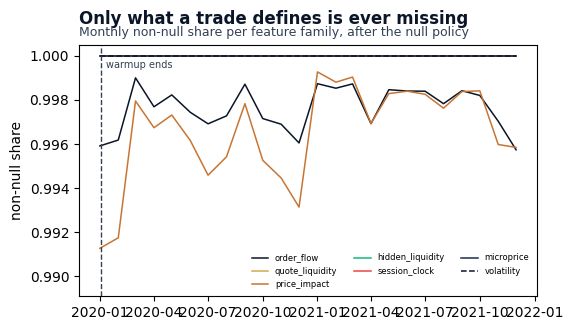

In [24]:
plot_coverage_through_time(
    coverage,
    warmup_boundary=features["timestamp"].min(),
    title="Only what a trade defines is ever missing",
    subtitle="Monthly non-null share per feature family, after the null policy",
    alt=(
        "Line chart of non-null share by feature family by month, on a y-axis spanning "
        "roughly 0.990 to 1.0. Five families - quote liquidity, microprice, volatility, hidden "
        "liquidity and session clock - lie exactly on one for the whole sample, drawn on top "
        "of each other as a single flat line at the top. The order flow family runs below it "
        "between about 0.9957 and 0.9990, and the price impact family is the lowest and most "
        "ragged, between about 0.9913 and 0.9993, dipping hardest in early 2020 and late 2020. "
        "The two lower lines track each other closely and both fall away in the final month."
    ),
)

### F4. The timing contract

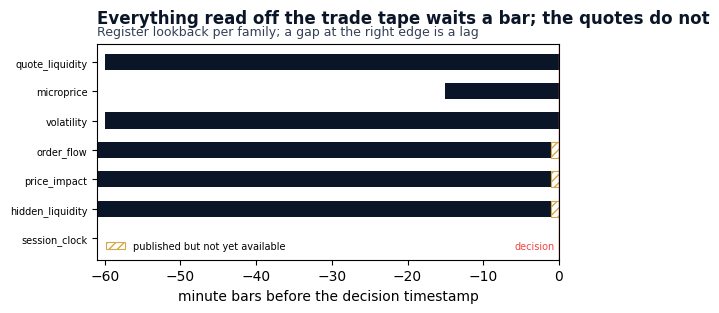

In [25]:
plot_timing_contract(
    FAMILIES,
    bar_unit="minute bars",
    title="Everything read off the trade tape waits a bar; the quotes do not",
    subtitle="Register lookback per family; a gap at the right edge is a lag",
    alt=(
        "Horizontal bars, one per feature family, each extending leftward from the decision "
        "line by that family's lookback: 60 minute bars for quote liquidity, volatility, "
        "order flow, price impact and hidden liquidity, 15 for the microprice family, and "
        "none for the session clock. The quote liquidity, volatility and microprice bars run "
        "flush to the decision line. The order flow, price impact and hidden liquidity bars "
        "each stop one bar short of it, and the gap is hatched - the delay with which a "
        "TRF print becomes public."
    ),
)

## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature
arrives on, whether the cross-section disagrees enough to rank on, how much of the set is
one ordering under several names, and how long a value lasts. Whether any of it predicts is
`05_evaluation`'s question, and it is asked there fold by fold rather than here on the
whole sample.

### F2. Feature distributions

The carrier family is shown on the scale a reader would judge it: the per-bar imbalance,
the same quantity over the fast, decision and hourly windows, and the decision-window
version in its cross-sectional form. Aggregating over more bars pulls the share toward
zero, and the z-score puts a bounded, heavily-tied quantity onto an unbounded one - which
is the point of carrying both.

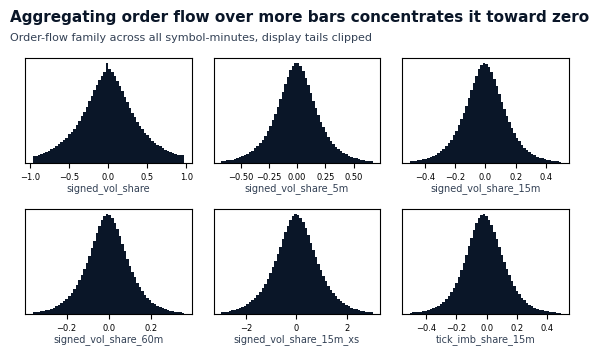

In [26]:
plot_feature_distributions(
    features,
    [
        "signed_vol_share",
        "signed_vol_share_5m",
        CARRIER,
        "signed_vol_share_60m",
        f"{CARRIER}_xs",
        "tick_imb_share_15m",
    ],
    title="Aggregating order flow over more bars concentrates it toward zero",
    subtitle="Order-flow family across all symbol-minutes, display tails clipped",
    alt=(
        "Six histograms in two rows. The per-bar signed volume share fills its full range "
        "from minus one to one, a broad symmetric peak at zero with tails that reach the "
        "bounds. The five-minute, fifteen-minute and sixty-minute aggregates are the same "
        "shape over progressively narrower ranges - about plus or minus 0.75, 0.5 and 0.3 - "
        "so each is a taller, tighter bell than the one before it. The cross-sectional "
        "z-score of the fifteen-minute share spans about minus three to three, and the "
        "fifteen-minute tick imbalance is close to its signed-volume twin."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a minute where the band
narrows to nothing there is nothing to rank, whatever the average level of order flow. This
reads the decision grid alone: a band drawn over every minute would describe a cadence no
decision is taken at.

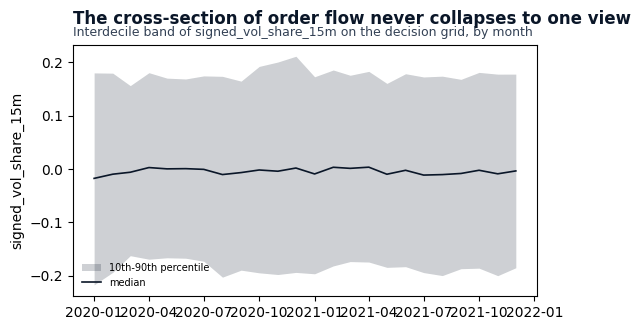

In [27]:
plot_cross_sectional_dispersion(
    decisions,
    CARRIER,
    every="1mo",
    title="The cross-section of order flow never collapses to one view",
    subtitle=f"Interdecile band of {CARRIER} on the decision grid, by month",
    alt=(
        "Shaded band of the 10th to 90th percentile of the fifteen-minute signed volume "
        "share across the universe, by month, with the median drawn through it. The median "
        "runs flat along zero for the whole sample. The band is roughly symmetric about it "
        "at plus or minus 0.18, holds that width from the start of 2020 to the end of 2021 "
        "with a slight bulge around late 2020, and never narrows toward the median."
    ),
)

### F5. Redundancy structure

Clustering on the distance $1 - |\rho|$ groups features that carry the same ordering,
whatever the sign. Above the cut two features are close enough that a linear model cannot
separate their contributions. This figure states the clusters and stops there. What
`05_evaluation` does next is narrower than picking one member of each: it counts the pairs
above the same threshold and triages every feature independently, so the choice of which
member to keep is a modelling decision and Chapter 11 makes it.

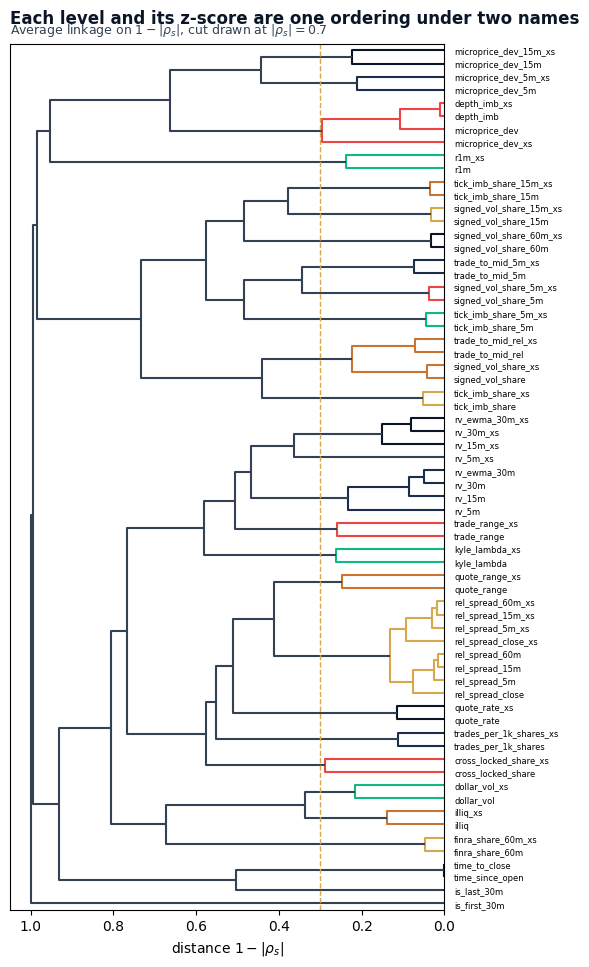

In [28]:
CUT = 0.7
clusters = plot_redundancy_clusters(
    features,
    feature_cols,
    cut=CUT,
    title="Each level and its z-score are one ordering under two names",
    subtitle=r"Average linkage on $1 - |\rho_s|$, cut drawn at $|\rho_s| = 0.7$",
    alt=(
        "Dendrogram of all 66 features, leaves labelled on the right. The dominant structure "
        "is that almost every level joins its own cross-sectional z-score at a distance near "
        "zero, so the tree reads as a column of tight pairs. Those pairs then group by "
        "family: the four spread windows with the quote rate, the signed-volume and tick "
        "imbalance horizons together, the three nested realized volatilities with the EWMA "
        "and the two ranges, and the microprice deviations with the depth imbalance. The "
        "off-exchange share pairs with its z-score and joins nothing else. At the foot, time "
        "since open and time to close form one pair at distance zero, because each is one "
        "minus the other; the last-30-minutes flag joins them around 0.5; and the "
        "first-30-minutes flag stands alone against the root, sharing an ordering with "
        "nothing because it is constant in this matrix."
    ),
)

Cutting the redundancy tree at $|\rho_s| = 0.7$ leaves **28 clusters** across the **66**
columns, so well over half the matrix repeats an ordering another column already carries.
Almost all of that is the level-and-z-score pairing, which is deliberate: the two are one
hypothesis on two scales and a model that can use either is meant to choose. Nothing here
or in `05_evaluation` drops a cluster member: the next stage reports the correlated pairs
and triages each feature on its own, and which member to keep is Chapter 11's choice.

In [29]:
print(f"{len(set(clusters.values()))} clusters over {len(feature_cols)} features at cut {CUT}")

28 clusters over 66 features at cut 0.7


### F6. Persistence and rank stability

The left panel is the autocorrelation of the feature itself, run out to ten rebalances of
the 15-minute schedule. It is estimated within the symbol-session, because every window in
this matrix restarts each morning and a pair of bars either side of a night is not a lag
of anything. The right panel asks the same question of the ordering rather than the level,
between consecutive decisions.

A feature whose value has decayed before the next rebalance cannot support that cadence,
however well it predicts on the bar it is computed. That is the whole of what this figure
decides, and it is why the carrier is carried at four windows rather than one.

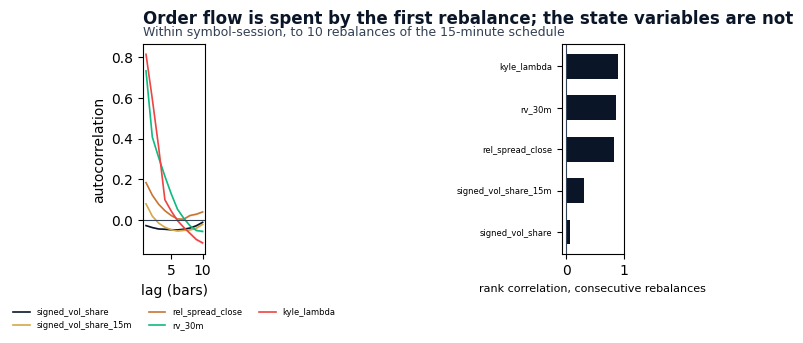

In [30]:
plot_persistence(
    decisions.with_columns(pl.col("timestamp").dt.date().alias("session_date")),
    ["signed_vol_share", CARRIER, "rel_spread_close", f"rv_{W['slow']}m", "kyle_lambda"],
    entity=ENTITY,
    max_lag=10,
    decision_dates=DECISION_TIMES.to_list(),
    title="Order flow is spent by the first rebalance; the state variables are not",
    subtitle=f"Within symbol-session, to 10 rebalances of the {DECISION_MINUTES}-minute schedule",
    alt=(
        "Two panels. On the left, autocorrelation against lag in decision bars, one to ten. "
        "Kyle's lambda and the thirty-minute realized volatility start above 0.8 at the first "
        "lag and fall steeply, reaching zero by about the eighth. The relative spread starts "
        "near 0.2 and decays gently to zero. Both order-flow series start at or below 0.05 "
        "and stay flat along zero for every lag. The bootstrap ribbons are too narrow to "
        "read. On the right, the cross-sectional rank correlation between consecutive "
        "rebalances: Kyle's lambda, the realized volatility and the relative spread form a "
        "tight group between about 0.75 and 0.85, the fifteen-minute signed volume share "
        "reaches about 0.3, and the per-bar one is close to zero."
    ),
)

## G. Emit

The parquet is written with a sidecar recording the digest of its values, its row count and
key columns, and the digest of what it was built from. This stage reads no upstream
case-study artifact - the labels are joined in `05_evaluation`, not here - so the sidecar
records the loaded minute panel alone, restricted to the columns and window actually
consumed. The digest is computed over content rather than file bytes, so row order and
parquet metadata leave it alone and any feature value moves it. That is the property the
registry's own hashes lack: a feature-set *name* reaches the registry, a feature-set
*value* does not.

In [31]:
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=PANEL_KEY,
    written_by="case_studies/nasdaq100_microstructure/03_financial_features.py",
    inputs={"load_nasdaq100_bars": value_digest(bars.select(READ))},
)
print(f"Wrote {display_path(FEATURES_DIR / 'financial.parquet')}, digest {record['digest']}")

Wrote /home/stefan/ml4t/code/case_studies/nasdaq100_microstructure/features/financial.parquet, digest baac4ffc0a5770f1


## Key takeaways

- **Bound every window by the session, not by the symbol.** An intraday statistic that
  spans a night measures the overnight gap, and on a minute grid that gap is larger than
  anything the feature is meant to see. Making the symbol-session the entity is what makes
  the warmup assertion in D.2 mean the same thing on every row.
- **Measure the session against the schedule, not against the bars that arrived.** The
  realized bar count is a whole-session aggregate, so a feature built on it is a quantity
  nobody had until the session ended - and on an early close the vendor's padded grid makes
  it wrong as well as unknowable.
- **A late-published input needs a lag, however short the delay looks.** Ten seconds is
  small against a one-minute bar and it is not zero, and the cost of deferring a
  sixty-minute average by one bar is nothing.
- **Use the library's estimator or rename the column.** The single-bar ratio this notebook
  shipped as Amihud illiquidity was a different statistic under a published name; the
  averaged form is what the literature and every other case study here mean by it.
- **Test the seal by construction, not by inspection.** Rebuilding the matrix with later
  dates withheld and comparing values catches any transform that fits across the sample,
  including the ones nobody thought to flag.

### Known limitations

- The matrix is at one-minute resolution while the decision grid is fifteen minutes, so a
  model trained on every row sees each 15-minute label fifteen times. The overlap is
  `05_evaluation`'s to price and the downstream models' to weight for; nothing here
  subsamples, because thinning the matrix would throw away the fast families it exists to
  carry.
- `is_first_30m` is identically zero in the emitted matrix. The hour of warmup Kyle's
  lambda needs removes every bar the flag marks, so the opening block of the session - the
  busiest part of the U - is not representable here at all. The column is kept for the
  feature count Chapter 8 reports and Section E asserts that it is dead, but a model has 65
  usable features, not 66, and the open is a gap in what this matrix can condition on.
- The vendor emits a padded 390-bar grid on early closes, so the three half-sessions in
  this window - 2020-11-27, 2020-12-24 and 2021-11-26 - carry bars stamped after the
  exchange had closed. The clock family is measured against the schedule and so reports
  them correctly, but they remain in the panel because the bar universe is `02_labels`'s to
  set and not this notebook's.
- Trade location is assigned against the prevailing quote, so a bar whose quote was stale
  attributes its volume to a side rather than to neither. The staleness cap bounds how long
  that can persist; it does not undo it on the bars inside the cap.
- Every feature here is a rule written in advance. `04_model_based_features` adds the
  features that are themselves model outputs, where the rule is estimated from the data.